In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pyabf
import os
import matplotlib.gridspec as gridspec

In [9]:
#Set directory 
directory = '/Users/jayashri/Desktop/04122025/'

In [11]:
def get_voltage_clamp_files(directory):
    """
    Identify all current clamp ABF files in a directory and extract their protocols.

    Parameters:
        directory (str): The path to the folder containing ABF files.

    Returns:
        dict: {filename: protocol_name} for all current clamp files.
    """
    voltage_clamp_files = {}

    for file in os.listdir(directory):
        if file.endswith(".abf"):
            file_path = os.path.join(directory, file)
            abf = pyabf.ABF(file_path)

            # Check if the recording is a Voltage Clamp File
            if "pA" in abf.sweepLabelY:
                protocol_name = abf.protocol if abf.protocol else "Unknown"
                voltage_clamp_files[file] = protocol_name

    return voltage_clamp_files

get_voltage_clamp_files(directory)

{'25413005.abf': '1_VC_MembTest',
 '25413003.abf': '1_VC_MembTest',
 '25413000.abf': '1_VC_MembTest',
 '25412027.abf': '1_VC_MembTest',
 '25412019.abf': '1_VC_MembTest',
 '25412025.abf': '1_VC_MembTest',
 '25412018.abf': '1_VC_MembTest',
 '25412008.abf': '1_VC_MembTest',
 '25412022.abf': '1_VC_MembTest',
 '25412013.abf': '1_VC_MembTest',
 '25412007.abf': '1_VC_MembTest',
 '25412004.abf': '1_VC_MembTest',
 '25412010.abf': '1_VC_MembTest',
 '25412005.abf': '1_VC_MembTest',
 '25412001.abf': '1_VC_MembTest',
 '25412015.abf': '1_VC_MembTest',
 '25412028.abf': '1_VC_MembTest',
 '25412000.abf': '1_VC_MembTest',
 '25412016.abf': '4_VC_EPSCs',
 '25412002.abf': '1_VC_MembTest'}

In [13]:
#Now get membrane test files 
def get_voltage_clamp_files_by_protocol(directory, target_protocol):
    """
    Identify all Voltage Clamp ABF files in a directory that use a specific protocol.

    Parameters:
        directory (str): The path to the folder containing ABF files.
        target_protocol (str): The exact name of the protocol to match.

    Returns:
        dict: {filename: protocol_name} for matching Voltage Clamp files.
    """
    matching_files = {}

    for file in os.listdir(directory):
        if file.endswith(".abf"):
            file_path = os.path.join(directory, file)
            abf = pyabf.ABF(file_path)

            if "pA" in abf.sweepLabelY:
                protocol_name = abf.protocol if abf.protocol else "Unknown"
                if protocol_name == target_protocol:
                    matching_files[file] = protocol_name

    return matching_files

# Example usage
    
get_voltage_clamp_files_by_protocol(directory, '1_VC_MembTest')

{'25413005.abf': '1_VC_MembTest',
 '25413003.abf': '1_VC_MembTest',
 '25413000.abf': '1_VC_MembTest',
 '25412027.abf': '1_VC_MembTest',
 '25412019.abf': '1_VC_MembTest',
 '25412025.abf': '1_VC_MembTest',
 '25412018.abf': '1_VC_MembTest',
 '25412008.abf': '1_VC_MembTest',
 '25412022.abf': '1_VC_MembTest',
 '25412013.abf': '1_VC_MembTest',
 '25412007.abf': '1_VC_MembTest',
 '25412004.abf': '1_VC_MembTest',
 '25412010.abf': '1_VC_MembTest',
 '25412005.abf': '1_VC_MembTest',
 '25412001.abf': '1_VC_MembTest',
 '25412015.abf': '1_VC_MembTest',
 '25412028.abf': '1_VC_MembTest',
 '25412000.abf': '1_VC_MembTest',
 '25412002.abf': '1_VC_MembTest'}

In [45]:
def save_avg_waveforms_as_json(directory, target_protocol="1_VC_MembTest", json_filename="membrane_test_averages.json"):
    """
    Save average waveforms from ABF files with a matching protocol into a JSON file.

    Parameters:
        directory (str): Folder with .abf files.
        target_protocol (str): Protocol name to match.
        json_filename (str): Name of output JSON file.

    Returns:
        dict: JSON-style dictionary {filename: {'time': [...], 'waveform': [...]}}.
    """
    result_dict = {}

    for file in os.listdir(directory):
        if file.endswith(".abf"):
            file_path = os.path.join(directory, file)
            abf = pyabf.ABF(file_path)

            if "pA" not in abf.sweepLabelY:
                continue

            if abf.protocol != target_protocol:
                continue

            all_sweeps = []
            for sweepNumber in range(abf.sweepCount):
                abf.setSweep(sweepNumber)
                all_sweeps.append(abf.sweepY)

            avg_waveform = np.mean(all_sweeps, axis=0)
            time_array = abf.sweepX

            result_dict[file] = {
                "time": time_array.tolist(),
                "waveform": avg_waveform.tolist(),
                "n_sweeps": abf.sweepCount
            }

            # Plot
            plt.figure(figsize=(8, 4))
            plt.plot(time_array, avg_waveform, label=f"Average of {abf.sweepCount} sweeps", color="navy")
            plt.title(f"Avg Waveform - {file}")
            plt.xlabel("Time (s)")
            plt.ylabel(abf.sweepLabelY)
            plt.grid(True)
            plt.legend()
            plt.tight_layout()
            plt.show()

    # Save to JSON file
    json_path = os.path.join(directory, json_filename)
    with open(json_path, "w") as f:
        json.dump(result_dict, f, indent=2)

    print(f"\n✅ Average waveforms saved to {json_path}")
    return result_dict

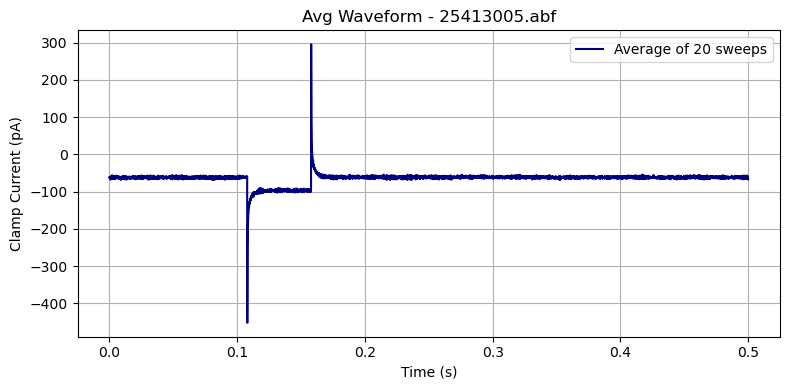

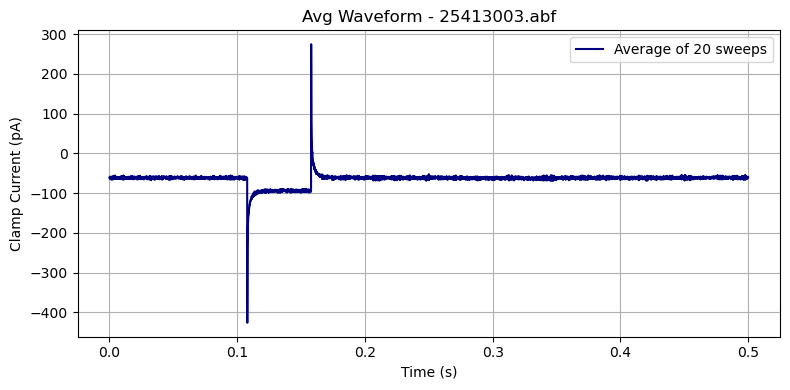

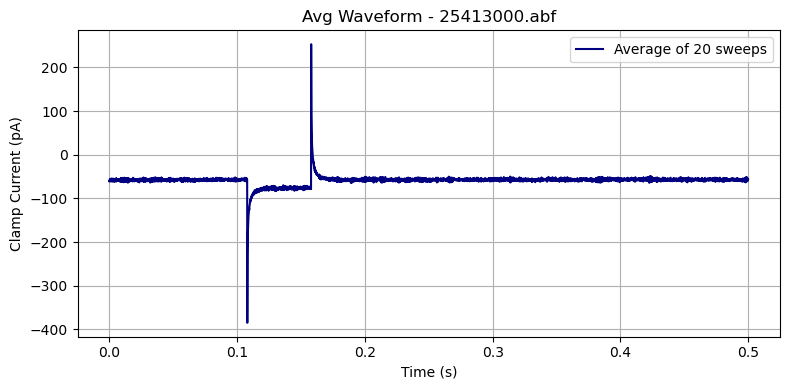

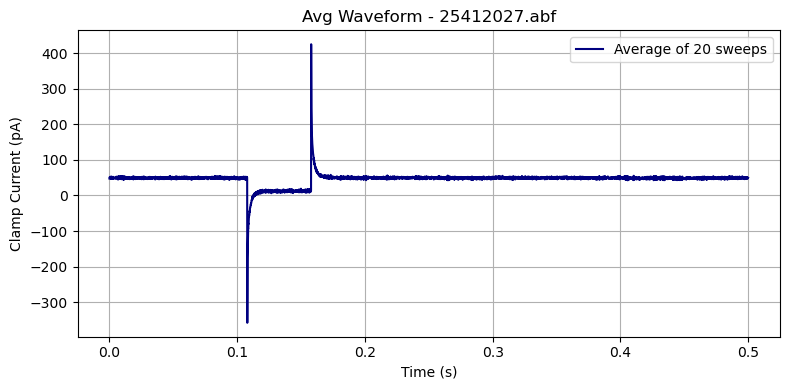

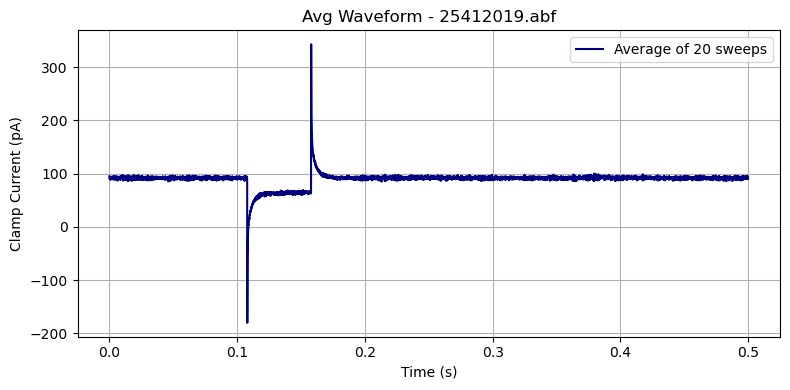

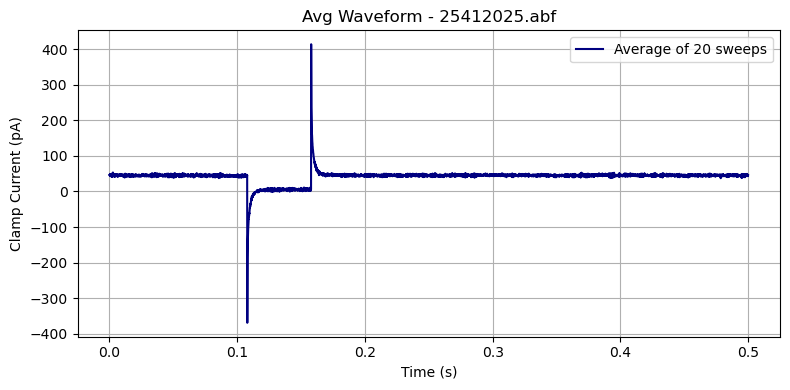

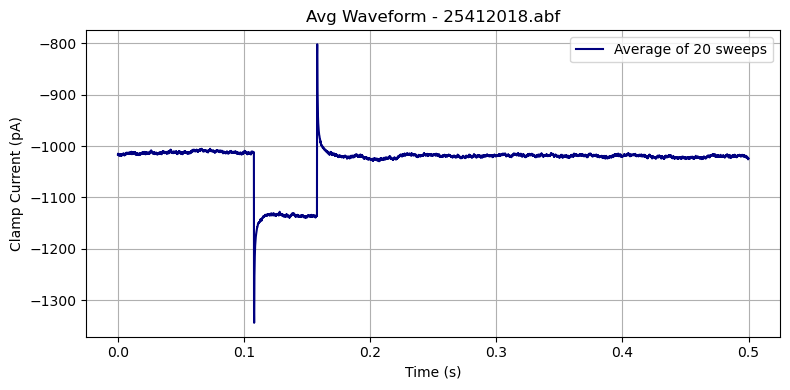

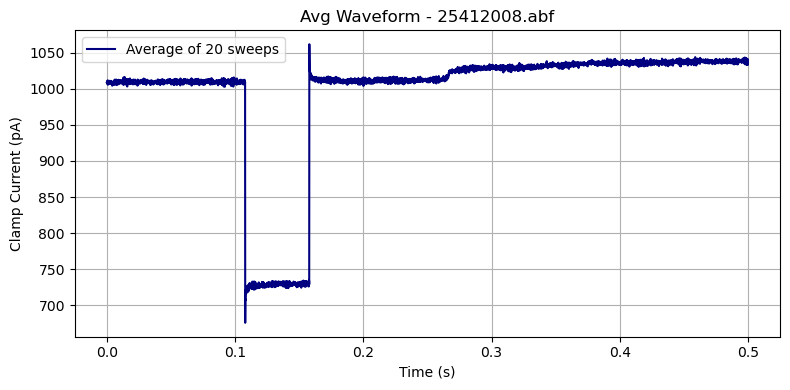

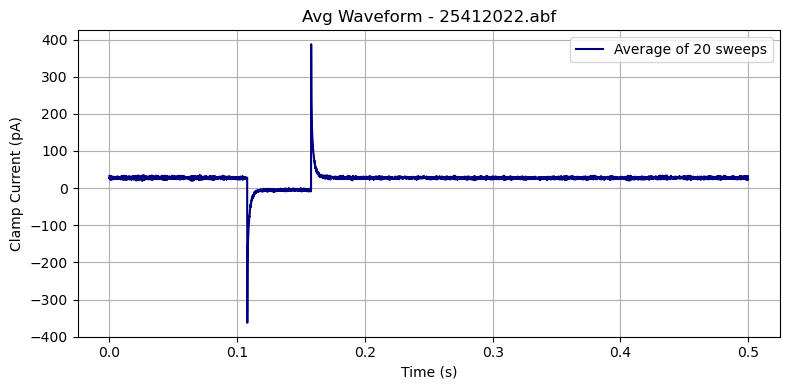

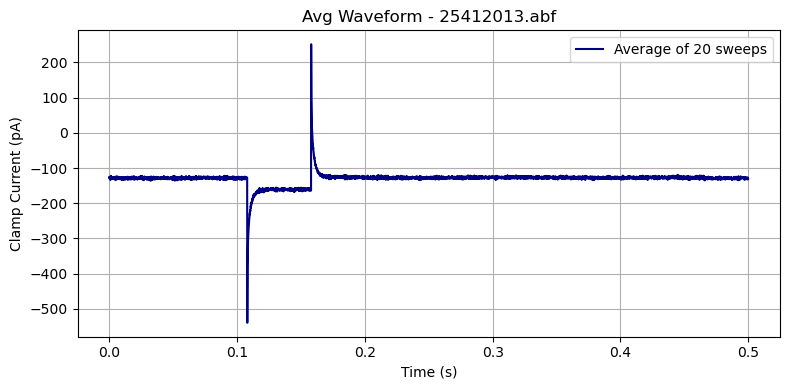

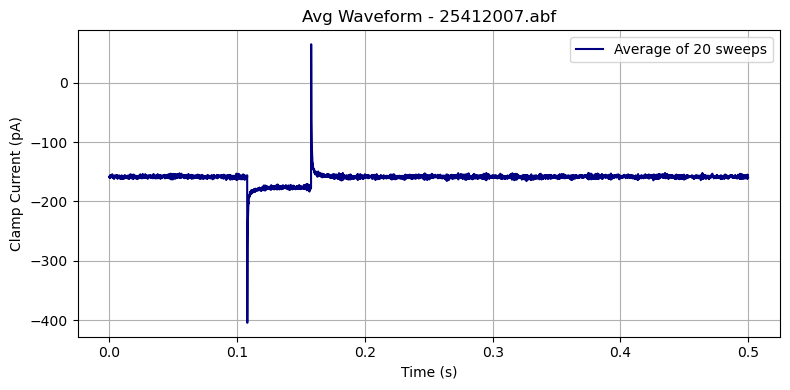

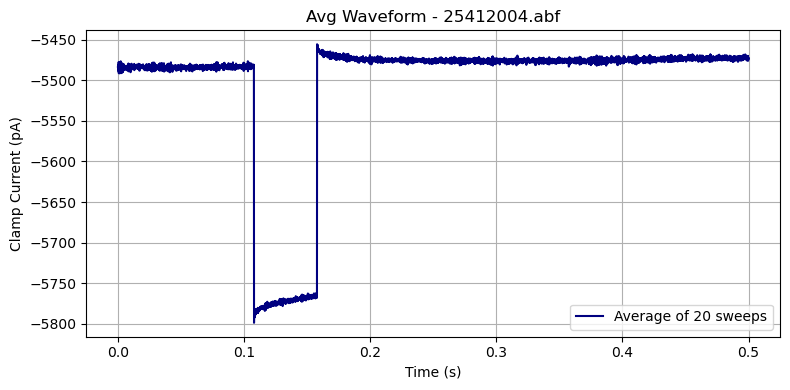

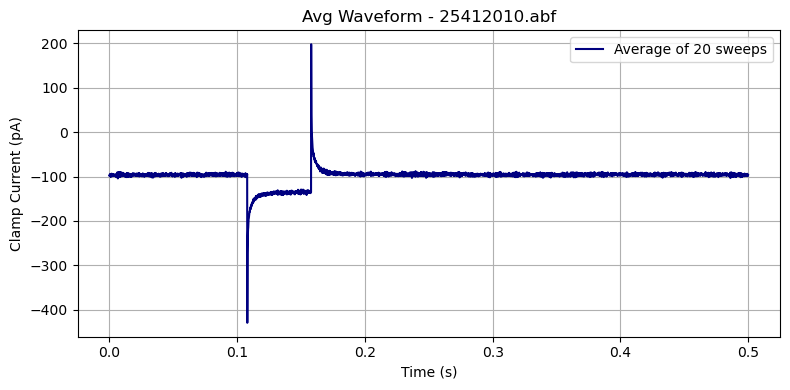

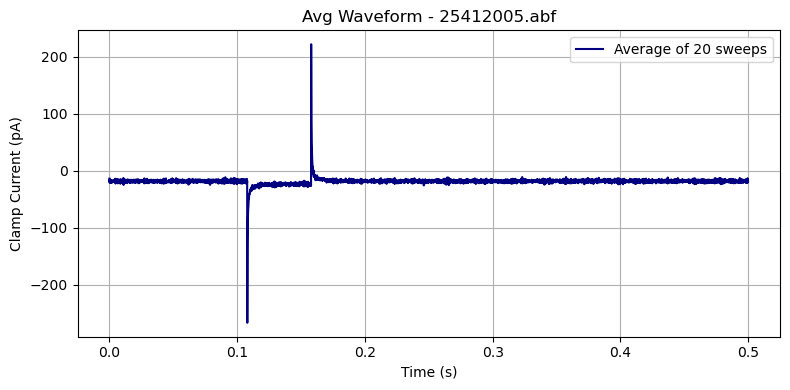

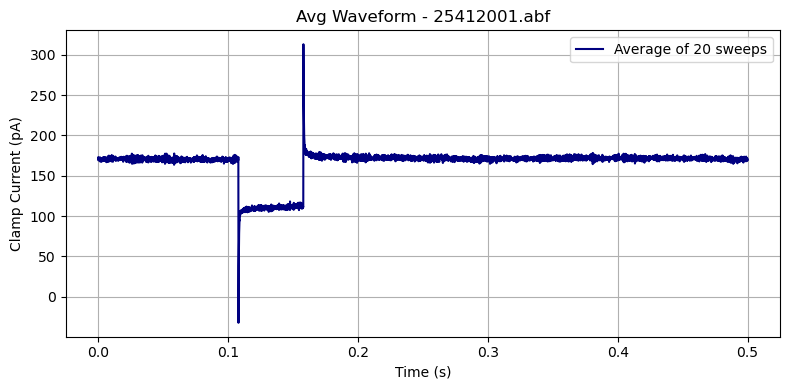

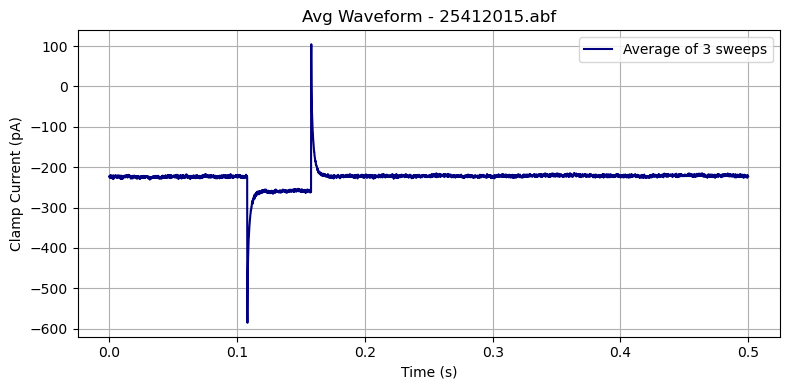

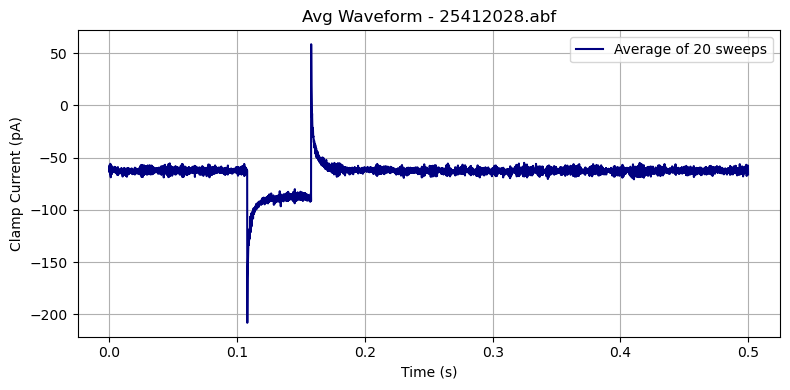

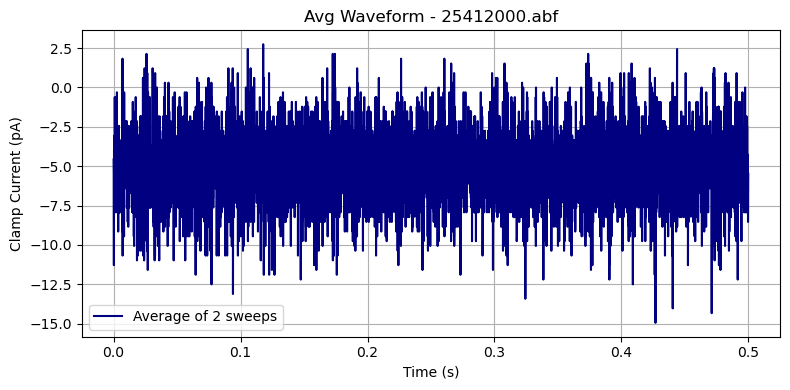

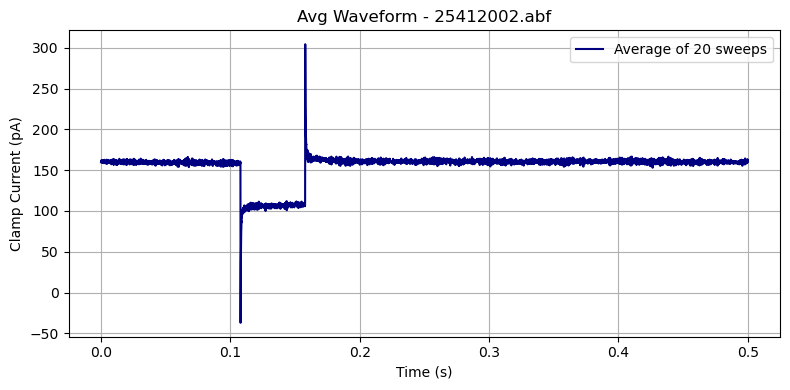


✅ Average waveforms saved to /Users/jayashri/Desktop/04122025/membrane_test_averages.json


In [49]:
data = save_avg_waveforms_as_json("/Users/jayashri/Desktop/04122025/")